**SNN Basics**

In [1]:
# Spiking Neuron Model
# Define inputs, weights for inputs, decay constant, firing threshold

class Spike_neuron():
    def __init__(self, weights, decay_c, fire_thresh, cooldown_thresh):
        self.potential = 0                      # Current Potential in the Neuron Body
        self.weights = weights                  # Weights for each input from previous layer
        self.decay_c = decay_c                  # Decay constant which represents how fast the potential drops back to resting
        self.fire_thresh = fire_thresh          # Threshold at which the neuron fires to the next neurons in the next layer
        self.output = 0                         # Output signal of this neuron(firing signal)
        self.cooldown_thresh = cooldown_thresh  # Cooldown timer, usually brain neurons after firing have a set period for which they cannot fire
        self.counter = 0                        # The counter to enforce this timing delay between subsequent spikes
    
    def accumulate(self, inputs):
        # If the neuron is in resting state(cooldown) then no inputs are recieved
        # If the neuron is accepting inputs then it is is the matrix product of the inputs with the weights to obtain a single value which is added and checked with potential
        # If the potential is high enough then se fire for this neuron
        if self.counter > 0:
            self.output = 0
            self.counter -= 1
        else:
            potential_gain = inputs.T @ self.weights
            self.potential += potential_gain
            if(self.potential >= self.fire_thresh):
                self.fire()
    
    def decay(self):
        # At each time step, the neuron is constantly losing potential and returning to resting potential(0)
        self.potential -= self.decay_c * self.potential
    
    def fire(self):
        # Firing involves setting the output to 1, setting potential back to 0, and setting a counter for cooldown
        self.output = 1
        self.potential = 0
        self.counter = self.cooldown_thresh


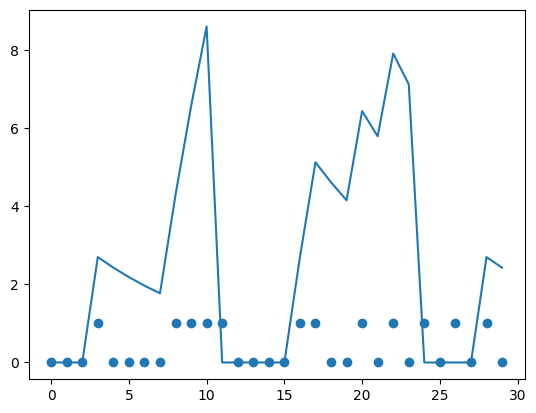

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Single Input to neuron mapped

weights = [3]
decay_c = 0.1
fire_thresh = 10
cooldown_thresh = 2

n1 = Spike_neuron(weights, decay_c, fire_thresh, cooldown_thresh)

inputs = [0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,0, 1, 0, 1, 0]
potentials = []
for i in range(len(inputs)):
    n1.accumulate(np.array([inputs[i]]))
    n1.decay()
    potentials.append(n1.potential)

x_s = np.arange(0,len(potentials), 1)

plt.plot(x_s, potentials)
plt.scatter(x_s, inputs)